# Plateau’s Problem for Enneper surface

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 

## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(0)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [49]:
from util.visualization.utils_mesh import get_mesh

# Parametric equations for Enneper's minimal surface in polar coordinates
def enneper_surface_polar(r, phi):
    x = r * torch.cos(phi) - (1/3) * r**3 * torch.cos(3 * phi)
    y = r * torch.sin(phi) + (1/3) * r**3 * torch.sin(3 * phi)
    z = r**2 * torch.cos(2 * phi)
    return x, y, z

def enneper_level_set(x):
    x1 = x[:, 0]
    y1 = x[:, 1]
    z1 = x[:, 2]
    
def enneper_level_set(x):
    x1 = x[:, 0]
    y1 = x[:, 1]
    z1 = x[:, 2]
    
    term1 = (y1**2 - x1**2) / (2 * z1) + (2 / 9) * z1**2 + 2 / 3
    term2 = (y1**2 - x1**2) / (4 * z1) - (1 / 4) * (x1**2 + y1**2 + (8 / 9) * z1**2) + 2 / 9
    
    return term1**3 - 6 * term2**2


# Bounds and number of samples
n = 1000
r_max = 1.0
phi = torch.linspace(-torch.pi, torch.pi, n, dtype=torch.float64)

# Generate boundary points with r constant and phi ranging from -pi to pi
r_constant = torch.full_like(phi, r_max, dtype=torch.float64)
x, y, z = enneper_surface_polar(r_constant, phi)
pts_boundary = torch.vstack([x, y, z]).T

# Generate the mesh using the level set function
verts, faces = get_mesh(
    enneper_level_set, N=512, device=device,
    bbox_min=torch.tensor([-3, -3, -3], dtype=torch.float64),
    bbox_max=torch.tensor([3, 3, 3], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()


Output()

### Define the boundary rectangles

In [57]:
pts_space = torch.rand([1000, 3], dtype=torch.float64)
pts_space_fixed = torch.rand([1000, 3], dtype=torch.float64)
pts_eikonal = torch.cat((pts_space_fixed, pts_boundary))
pts_corners = torch.empty_like(pts_boundary, dtype=torch.float64)
# pts_eikonal = pts_space_fixed

loss_weights = {"interface": 1.0, "interface_corners": 0.0, "eikonal": 0.001, "laplacian": 1.0}

config = {
    "pts_boundary": pts_boundary,
    "pts_corners": pts_corners,
    "pts_eikonal": pts_eikonal,
    "pts_space": pts_space,
    "loss_weights": loss_weights,
}

### Point-sampler demo

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

### Main training loop

  0%|          | 0/1000 [00:00<?, ?it/s]

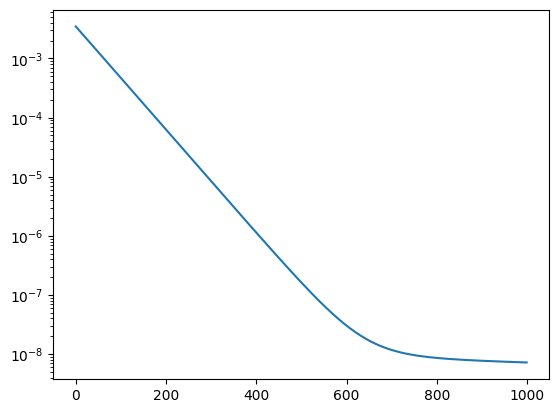

In [58]:
import time

model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
params = model.params
# Gauss-Newton:
# loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.001, "laplacian": 1.0}
optim = HandNGD(model, lr=1e-2, config=config)
# Adam:
# loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.4, "laplacian": 1.0}
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik

sample_on_surface = False
sampling_method = "binary_search" # one of ["random", "binary_search"]
surf_pts_nof_points = 100000 ## approx number to initialize the search with
bounds = torch.tensor([[0,1], [0,1], [0,1]], dtype=torch.float64)

loss_over_iters = {}
loss_over_time = {}
start_time = time.time()

for i in (pbar:=trange(1000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()
    loss_interface += loss_weights["interface_corners"] * 0.5*model.f(params, pts_corners).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    if sample_on_surface:
        if sampling_method=="random":
            pts_space = torch.rand([10000, 3], dtype=torch.float64)
            vals_sq = model(pts_space).square().squeeze()
            pts = pts_space[vals_sq<1e-4]
            if len(pts):
                pts_space = pts
        elif sampling_method=="binary_search":
            grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
                surf_pts_nof_points, bounds, equidistant=True)

            success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
                netp=netp, 
                z=torch.zeros([1,0], dtype=torch.float64), ## or correct shape with degenerate shape 
                n_steps=10,
                x_grid=grid_find_surface, 
                x_grid_dist=grid_dist_find_surface, 
                level_set=0.0,
                nf_is_density=True,
                resolution=init_grid_resolution
                )
            if success:
                pts_space = p_surface.data
                pts_space = torch.cat((pts_space_fixed, pts_space))
            else:
                pts_space = pts_space_fixed
                # print("Warning: failed. Surface points will be outdated.")
                pass ## TODO: probably need to have a fallback to handle this case, and nans more generally
        else:
            assert False, "Point sampling method unknown"
        # pts_space = torch.cat((pts_space_fixed, pts_space))
        config["pts_space"] = pts_space
        optim.config = config
    loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()
       
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts_space)}"
                            )
        loss_over_iters[i] = loss_metric.item()
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()
        
    optim.loss = loss_metric
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [59]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Visualize the result